In [1]:
import zipfile
import datetime
import string
import math
import os

import tqdm
import matplotlib.pyplot as plt
import tensorflow as tf
import sklearn.model_selection

import keras_ocr
import tensorflow as tf 
from utils import get_text_generator

In [2]:
## Generating synthetic data
assert tf.test.is_gpu_available(), 'No GPU is available.'

Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.


2025-03-19 11:08:22.179540: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2025-03-19 11:08:22.179742: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2025-03-19 11:08:22.179749: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.00 GB
2025-03-19 11:08:22.180303: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:303] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-03-19 11:08:22.180755: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:269] Created TensorFlow device (/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [ ]:
data_dir = '.'
alphabet = string.digits + string.ascii_letters + '+-×±Φφ. '
fonts = keras_ocr.data_generation.get_fonts(
    alphabet=alphabet,
    cache_dir=data_dir
)
myfonts = [
    './myfonts/fangsong_GB2312.ttf', 
    './myfonts/GenShinGothic-Medium.ttf', 
    './myfonts/GenShinGothic-Monospace-Normal.ttf', 
    './myfonts/GenShinGothic-Normal.ttf', 
    './myfonts/GenShinGothic-P-Normal.ttf', 
    './myfonts/GenShinGothic-Regular.ttf', 
    './myfonts/kaiti_GB2312.ttf', 
    './myfonts/msyh.ttf', 
    './myfonts/simhei.ttf', 
    './myfonts/songti.ttf'
]
for myfont in myfonts:
    fonts.append(myfont)

backgrounds = keras_ocr.data_generation.get_backgrounds(cache_dir=data_dir)
mybackgrounds = [
    './mybackgrounds/bg1.jpg',
    './mybackgrounds/bg2.jpg',
    './mybackgrounds/bg3.jpg',
    './mybackgrounds/bg4.jpg',
    './mybackgrounds/bg5.jpg',
    './mybackgrounds/bg6.jpg',
    './mybackgrounds/bg7.jpg',
    './mybackgrounds/bg8.jpg',
    './mybackgrounds/bg9.jpg',
    './mybackgrounds/bg10.jpg',
]
for mybackground in mybackgrounds:
    backgrounds.append(mybackground)

Looking for ./fonts.zip


Filtering fonts.: 100%|██████████| 2746/2746 [00:03<00:00, 731.32it/s]


Looking for ./backgrounds.zip


In [4]:
fonts

['./fonts/ubuntumono/UbuntuMono-BoldItalic.ttf',
 './fonts/ubuntumono/UbuntuMono-Bold.ttf',
 './fonts/ubuntumono/UbuntuMono-Italic.ttf',
 './fonts/ubuntumono/UbuntuMono-Regular.ttf',
 './fonts/seoulhangang/SeoulHangang-Light.ttf',
 './fonts/seoulhangang/SeoulHangang-Bold.ttf',
 './fonts/seoulhangang/SeoulHangang-ExtraBold.ttf',
 './fonts/seoulhangang/SeoulHangang-Medium.ttf',
 './fonts/opensanscondensed/OpenSansCondensed-Bold.ttf',
 './fonts/opensanscondensed/OpenSansCondensed-LightItalic.ttf',
 './fonts/opensanscondensed/OpenSansCondensed-Light.ttf',
 './fonts/mplus1p/Mplus1p-ExtraBold.ttf',
 './fonts/mplus1p/Mplus1p-Light.ttf',
 './fonts/mplus1p/Mplus1p-Bold.ttf',
 './fonts/mplus1p/Mplus1p-Black.ttf',
 './fonts/mplus1p/Mplus1p-Medium.ttf',
 './fonts/mplus1p/Mplus1p-Regular.ttf',
 './fonts/tinos/Tinos-Regular.ttf',
 './fonts/tinos/Tinos-Italic.ttf',
 './fonts/tinos/Tinos-Bold.ttf',
 './fonts/tinos/Tinos-BoldItalic.ttf',
 './fonts/jejuhallasan/JejuHallasan-Regular.ttf',
 './fonts/tuffy

In [5]:
# text_generator = keras_ocr.data_generation.get_text_generator(alphabet=alphabet)
text_generator = get_text_generator(alphabet=alphabet)
print('The first generated text is:', next(text_generator))

The first generated text is: 98×Φ99


In [6]:
def get_train_val_test_split(arr):
    train, valtest = sklearn.model_selection.train_test_split(arr, train_size=0.8, random_state=42)
    val, test = sklearn.model_selection.train_test_split(valtest, train_size=0.5, random_state=42)
    return train, val, test

In [7]:
background_splits = get_train_val_test_split(backgrounds)
font_splits = get_train_val_test_split(fonts)

In [8]:
image_generators = [
    keras_ocr.data_generation.get_image_generator(
        height=640,
        width=640,
        text_generator=text_generator,
        font_groups={
            alphabet: current_fonts
        },
        backgrounds=current_backgrounds,
        font_size=(60, 120),
        margin=50,
        rotationX=(-0.05, 0.05),
        rotationY=(-0.05, 0.05),
        rotationZ=(-15, 15)
    )  for current_fonts, current_backgrounds in zip(
        font_splits,
        background_splits
    )
]

The first generated validation image (below) contains: j3
6


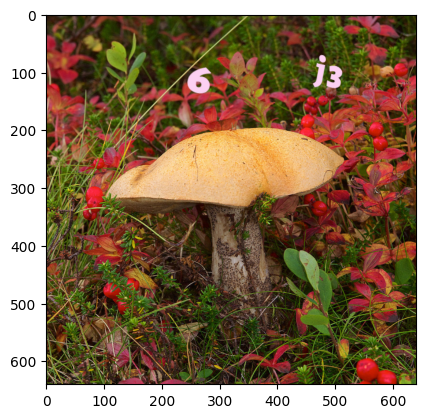

In [9]:
image, lines = next(image_generators[1])
text = keras_ocr.data_generation.convert_lines_to_paragraph(lines)
print('The first generated validation image (below) contains:', text)
plt.imshow(image)

In [16]:
detector = keras_ocr.detection.Detector(weights='clovaai_general')

Looking for /Users/ywu/.keras-ocr/craft_mlt_25k.h5


2025-03-19 13:00:49.593415: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-03-19 13:00:49.640900: W tensorflow/c/c_api.cc:304] Operation '{name:'upconv4.conv.0/bias/Assign' id:5785 op device:{requested: '', assigned: ''} def:{{{node upconv4.conv.0/bias/Assign}} = AssignVariableOp[_has_manual_control_dependencies=true, dtype=DT_FLOAT, validate_shape=false](upconv4.conv.0/bias, upconv4.conv.0/bias/Initializer/zeros)}}' was changed by setting attribute after it was run by a session. This mutation will have no effect, and will trigger an error in the future. Either don't modify nodes after running them or create a new session.
2025-03-19 13:00:49.760593: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-03-19 13:00:50.017328: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for de

In [ ]:
## Train the detector
detector_batch_size = 1
detector_basepath = os.path.join(data_dir, f'detector_{datetime.datetime.now().isoformat()}')
detection_train_generator, detection_val_generator, detection_test_generator = [
    detector.get_batch_generator(
        image_generator=image_generator,
        batch_size=detector_batch_size
    ) for image_generator in image_generators
]
detector.model.fit(
    detection_train_generator,
    steps_per_epoch=math.ceil(len(background_splits[0]) / detector_batch_size),
    epochs=10,
    workers=0,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(restore_best_weights=True, patience=5),
        tf.keras.callbacks.CSVLogger(f'{detector_basepath}.csv'),
        tf.keras.callbacks.ModelCheckpoint(filepath=f'{detector_basepath}.h5')
    ],
    validation_data=detection_val_generator,
    validation_steps=math.ceil(len(background_splits[1]) / detector_batch_size),
    batch_size=detector_batch_size
)

In [10]:
# TensorFlow 2.x compatibility
# 这两行代码一定要在model.compile()之前执行 
tf.compat.v1.disable_eager_execution()
tf.compat.v1.experimental.output_all_intermediates(True)
# recognizer_alphabet = ''.join(sorted(set(alphabet)))
recognizer_alphabet = alphabet
recognizer = keras_ocr.recognition.Recognizer(
    alphabet=recognizer_alphabet,
    weights='kurapan'
)
recognizer.compile()
for layer in recognizer.backbone.layers:
    layer.trainable = False

Instructions for updating:
Colocations handled automatically by placer.


2025-03-19 11:09:36.226410: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:303] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-03-19 11:09:36.226425: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:269] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2025-03-19 11:09:36.292044: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:303] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-03-19 11:09:36.292063: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:269] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL,

2025-03-19 11:09:36.435031: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


Provided alphabet does not match pretrained alphabet. Using backbone weights only.
Looking for /Users/ywu/.keras-ocr/crnn_kurapan_notop.h5


2025-03-19 11:09:36.779457: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-03-19 11:09:36.791808: W tensorflow/c/c_api.cc:304] Operation '{name:'lstm_11_back/lstm_cell/bias/Assign' id:1611 op device:{requested: '', assigned: ''} def:{{{node lstm_11_back/lstm_cell/bias/Assign}} = AssignVariableOp[_has_manual_control_dependencies=true, dtype=DT_FLOAT, validate_shape=false](lstm_11_back/lstm_cell/bias, lstm_11_back/lstm_cell/bias/Initializer/concat)}}' was changed by setting attribute after it was run by a session. This mutation will have no effect, and will trigger an error in the future. Either don't modify nodes after running them or create a new session.
2025-03-19 11:09:36.832492: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-03-19 11:09:36.882161: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registr

In [11]:
max_length = 10
recognition_image_generators = [
    keras_ocr.data_generation.convert_image_generator_to_recognizer_input(
        image_generator=image_generator,
        max_string_length=min(recognizer.training_model.input_shape[1][1], max_length),
        target_width=recognizer.model.input_shape[2],
        target_height=recognizer.model.input_shape[1],
        margin=1
    ) for image_generator in image_generators
]

This image contains: 93


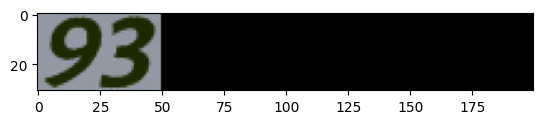

In [12]:
# See what the first validation image for recognition training looks like.
image, text = next(recognition_image_generators[1])
print('This image contains:', text)
plt.imshow(image)

In [13]:
recognition_batch_size = 8
recognizer_basepath = os.path.join(data_dir, f'recognizer_{datetime.datetime.now().isoformat()}')
recognition_train_generator, recognition_val_generator, recognition_test_generator = [
    recognizer.get_batch_generator(
    image_generator=image_generator,
    batch_size=recognition_batch_size,
    lowercase=False
    ) for image_generator in recognition_image_generators
]

In [14]:
recognizer.training_model.fit(
    recognition_train_generator,
    epochs=10,
    steps_per_epoch=math.ceil(len(background_splits[0]) / recognition_batch_size),
    callbacks=[
        tf.keras.callbacks.EarlyStopping(restore_best_weights=True, patience=25),
        tf.keras.callbacks.CSVLogger(f'{recognizer_basepath}.csv', append=True),
        tf.keras.callbacks.ModelCheckpoint(filepath=f'{recognizer_basepath}.h5')
    ],
    validation_data=recognition_val_generator,
    validation_steps=math.ceil(len(background_splits[1]) / recognition_batch_size),
    workers=0,
    # batch_size=recognition_batch_size
)

Epoch 1/10


2025-03-19 11:09:51.573684: W tensorflow/c/c_api.cc:304] Operation '{name:'bn_7/AssignMovingAvg_1/AssignSubVariableOp' id:320 op device:{requested: '', assigned: ''} def:{{{node bn_7/AssignMovingAvg_1/AssignSubVariableOp}} = AssignSubVariableOp[_class=["loc:@bn_7/moving_variance"], _has_manual_control_dependencies=true, dtype=DT_FLOAT](bn_7/moving_variance, bn_7/AssignMovingAvg_1/mul)}}' was changed by setting attribute after it was run by a session. This mutation will have no effect, and will trigger an error in the future. Either don't modify nodes after running them or create a new session.
2025-03-19 11:09:51.650897: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-03-19 11:09:51.676485: W tensorflow/c/c_api.cc:304] Operation '{name:'training/RMSprop/bn_7/gamma/rms/Assign' id:3279 op device:{requested: '', assigned: ''} def:{{{node training/RMSprop/bn_7/gamma/rms/Assign}} = AssignVariableOp[_has_manu

104/104 [==============================] - ETA: 0s - batch: 51.5000 - size: 8.0000 - loss: 14.2191

/opt/miniconda3/envs/ocr/lib/python3.10/site-packages/keras/src/engine/training_v1.py:2335: UserWarning: `Model.state_updates` will be removed in a future version. This property should not be used in TensorFlow 2.0, as `updates` are applied automatically.
  updates = self.state_updates
2025-03-19 11:19:33.803038: W tensorflow/c/c_api.cc:304] Operation '{name:'loss/mul' id:2316 op device:{requested: '', assigned: ''} def:{{{node loss/mul}} = Mul[T=DT_FLOAT, _has_manual_control_dependencies=true](loss/mul/x, loss/lambda_3_loss/value)}}' was changed by setting attribute after it was run by a session. This mutation will have no effect, and will trigger an error in the future. Either don't modify nodes after running them or create a new session.
2025-03-19 11:19:33.889370: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-03-19 11:19:40.447867: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_regis

104/104 [==============================] - 590s 6s/step - batch: 51.5000 - size: 8.0000 - loss: 14.2191 - val_loss: 12.6797
Epoch 2/10
104/104 [==============================] - 586s 6s/step - batch: 51.5000 - size: 8.0000 - loss: 9.0333 - val_loss: 8.7719
Epoch 3/10
104/104 [==============================] - 581s 6s/step - batch: 51.5000 - size: 8.0000 - loss: 4.8667 - val_loss: 4.8458
Epoch 4/10
104/104 [==============================] - 583s 6s/step - batch: 51.5000 - size: 8.0000 - loss: 3.9413 - val_loss: 4.6348
Epoch 5/10
104/104 [==============================] - 583s 6s/step - batch: 51.5000 - size: 8.0000 - loss: 2.9985 - val_loss: 2.7839
Epoch 6/10
104/104 [==============================] - 587s 6s/step - batch: 51.5000 - size: 8.0000 - loss: 2.7862 - val_loss: 3.2448
Epoch 7/10
104/104 [==============================] - 587s 6s/step - batch: 51.5000 - size: 8.0000 - loss: 2.4595 - val_loss: 2.8965
Epoch 8/10
104/104 [==============================] - 586s 6s/step - batch: 51

/opt/miniconda3/envs/ocr/lib/python3.10/site-packages/keras/src/engine/training_v1.py:2359: UserWarning: `Model.state_updates` will be removed in a future version. This property should not be used in TensorFlow 2.0, as `updates` are applied automatically.
  updates=self.state_updates,
2025-03-19 13:00:54.823698: W tensorflow/c/c_api.cc:304] Operation '{name:'conv_cls.8/BiasAdd' id:6028 op device:{requested: '', assigned: ''} def:{{{node conv_cls.8/BiasAdd}} = BiasAdd[T=DT_FLOAT, _has_manual_control_dependencies=true, data_format="NHWC"](conv_cls.8/Conv2D, conv_cls.8/BiasAdd/ReadVariableOp)}}' was changed by setting attribute after it was run by a session. This mutation will have no effect, and will trigger an error in the future. Either don't modify nodes after running them or create a new session.
2025-03-19 13:00:54.937151: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-03-19 13:00:55.542527: W tenso

Actual: p p m
9 . 9
3 Predicted: ['ppm', '9.9', '3']


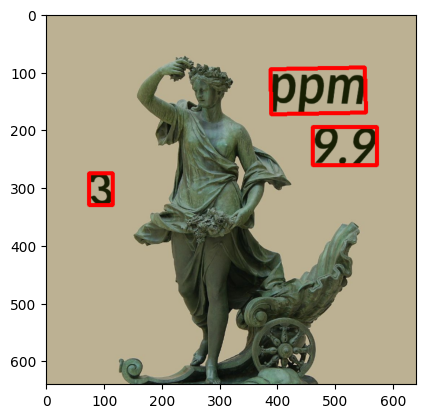

In [17]:
## Use the models for inference
pipeline = keras_ocr.pipeline.Pipeline(detector=detector, recognizer=recognizer)
image, lines = next(image_generators[0])
predictions = pipeline.recognize(images=[image])[0]
drawn = keras_ocr.tools.drawBoxes(
    image=image, boxes=predictions, boxes_format='predictions'
)
print(
    'Actual:', '\n'.join([' '.join([character for _, character in line]) for line in lines]),
    'Predicted:', [text for text, box in predictions]
)
plt.imshow(drawn)